# Novelty Detection with One-class SVM

----------------------------------------------------
Machine Learning    

*Vanessa Gómez Verdejo vanessa@tsc.uc3m.es* and *Emilio Parrado Hernández emipar@tsc.uc3m.es*

----------------------------------------------------

In [1]:
import matplotlib.pyplot as plt
import numpy as np


from sklearn import cluster, datasets
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import rbf_kernel

## Novelty detection problems

**Novelty detection** is one of the typical unsupervised learning scenarios. Mathematically it can be understood as the **learning of the limits** of the data distribution.

### Applications that demand novelty detection:

- Cleaning training sets of **outliers**.
- Deciding when the statistics governing data distributions have changed enough to require a model update.

Although the models we are going to see in this session can be used in both applications, for simplicity, we are going to focus on **outlier detection**.

## Outlier detection

Outliers are rare values that deviate from other observations on data; in other words, an outlier is an observation that is far from the rest of the observations or the center of mass of observations. Outlier detection estimators, thus, try to fit the regions where the training data is the most concentrated, ignoring the deviant observations.

Outliers can be caused human, instrumental or processing errors, for example, during the data acquisition, recording or processing or, measurement or experimental errors.

In machine learning is important to identify and remove outliers from data when training algorithms for predictive modeling.
Outliers can skew statistical measures and data distributions, providing a misleading representation of the underlying data and relationships. Removing outliers from training data prior to modeling can result in a better fit of the data and, in turn, more skillful predictions.


<img src='http://www.tsc.uc3m.es/~emipar/BBVA/AVANZATED/novelty_detection.png' width=500 />

As outlier detection consists in detecting the observations that are far from the rest of the observations, most of the methods are based in probability density estimation, such us using the **Gaussian Mixture Model (GMM)**. However, we can also use specific formulations of the SVM  as the  **One-class SVM (1-SVM)**.


## One class SVMs

The aim is to extend the SVM methodology (kernels, soft margin, sparsity, robust optimisation) to the resolution of novelty detection problems.

SVM is a classification algorithm, but in a novelty detection problem we are only going to have examples of the positive class...

There are two approaches to **one-class SVM**:
- Binary classification where the positive class consists of all observations in the training set and the negative class is the origin (point $\mathbf 0$) of the feature space.
- Hyper-sphere encompassing all observations in the training set.


### Classification against origin

We define the following binary classification problem **in a feature space** induced by a **kernel** function:
- The positive class is the examples of the training set on which we want to apply outlier detection.
- The negative class is the origin of coordinates in the feature space (the point $\bf 0$).
- The classification problem consists of finding the hyperplane that separates the observations of the training set from the origin with **maximum margin**.
- The formulation with **soft margin** allows some of the observations to fall on the wrong side of the margin, i.e., to be declared *outliers*, in exchange for obtaining a **softer** novelty detection function.

<img src='http://www.tsc.uc3m.es/~emipar/BBVA/AVANZATED/ocsvm_plano.png' width=500 />

#### Formulation

$$
\begin{aligned}
\min_{\mathbf{w}, b, \xi_i} \quad & -b + \frac{1}{2}\|\mathbf{w}\|^2 + C\sum_{i=1}^n \xi_i \\
\text{s.t.} \quad & \mathbf{w}^\top \phi(\mathbf{x}_i) \ge b - \xi_i, \quad i=1,\dots,n \\
& \xi_i \ge 0, \quad i=1,\dots,n
\end{aligned}
$$

The first constraint ensures all samples lie on the correct side of the margin.

Dual formulation:

$$
\begin{aligned}
\min_{\mathbf{a}} \quad & \frac{1}{2} \mathbf{a}^\top K \mathbf{a} \\
\text{s.t.} \quad & \sum_{i=1}^n a_i = 1 \\
& 0 \le a_i \le C, \quad i=1,\dots,n
\end{aligned}
$$

where:
- $\mathbf{a}$ are the coefficients of the dual problem (Lagrange multipliers of the constraints in the optimisation), i.e. $\mathbf{w} = \Phi^\top \mathbf{a}$
- $K$ is the kernel matrix $K = \Phi \Phi^\top$, $K_{ij} = \kappa(\mathbf{x}_i, \mathbf{x}_j)$
- The *outliers* verify $\sum_{i=1}^n a_i \kappa(\mathbf{x}_i, \mathbf{x}) + b < 0$

### Hyper-sphere encompassing the data

We also start by selecting a **kernel** function that induces a **feature space** on which the observations of the training set are projected.

The problem to be solved is to find the **radius** and **centre** of the smallest sphere of the feature space containing all the projections of the training observations.

The **soft margin** formulation allows some observations to fall outside the sphere, being considered as **outliers**.

#### Formulation of the One Class SVM with Hyperspheres

The optimization problem is to find the **hypersphere of smallest radius** that encompasses all the observations in the training set.

To define a hypersphere we need to specify the **centre** $\mathbf{c}$ and the **radius** $r$.

$$
\begin{aligned}
\min_{\mathbf{c}, r} \quad & r^2 \\
\text{s.t.} \quad & \|\phi(\mathbf{x}_i) - \mathbf{c}\|^2 \le r^2, \quad i=1,\dots,n
\end{aligned}
$$

We can adapt this formulation to a **soft margin** situation, and allow some observations to be **outside the hypersphere**. This is done by introducing the *slack variables* and the hyperparameter $C$ as is done in the SVM for classification:

$$
\begin{aligned}
\min_{\mathbf{c}, r, \xi_i} \quad & r^2 + C\sum_{i=1}^n \xi_i \\
\text{s.t.} \quad & \|\phi(\mathbf{x}_i) - \mathbf{c}\|^2 \le r^2 + \xi_i, \quad i=1,\dots,n \\
& \xi_i \ge 0, \quad i=1,\dots,n
\end{aligned}
$$

To solve the optimisation we first introduce the constraints on the functional using Lagrange multipliers.

$$
\min_{\mathbf c, r, \xi_i} \max_{\alpha_i, \eta_i}~~~ r^2 + C\sum_{i=1}^n{\xi_i} +\sum_{i=1}^n{\alpha_i\left( \|\mathbf \phi_i - \mathbf c\|^2 - r^2 - \xi_i\right)}-\sum_{i=1}^n \eta_i\xi_i
$$

Optimising with respect to $r$

$$
2r  -2\sum_{i=1}^n{r\alpha_i} = 0 \Rightarrow \sum_{i=1}^n{\alpha_i}=1
$$




Optimising with respect to $\mathbf c$

$$
\nabla_{\mathbf c}\left \{\sum_{i=1}^n{\alpha_i}\left( \mathbf \phi_i^\top\mathbf \phi_i - 2 \mathbf c^\top \mathbf \phi_i + \mathbf c^\top \mathbf c\right) \right \}= \mathbf 0 \Rightarrow \mathbf c = \sum_{i=1}^n{\alpha_i\mathbf \phi_i}
$$

Finally, optimising with respect to the *slack* varaibles $\xi_i$

$$
C - \alpha_i -\eta_i = 0 \Rightarrow 0 \le \alpha_i\le C
$$

Grouped together, the problem to be solved is

$$
\max_{\alpha_i}  \sum_{i=1}^n{\alpha_i\mathbf \phi_i^\top \mathbf \phi_i} -\sum_{i,j=1}^n{\alpha_i\alpha_j\mathbf \phi_i^\top\mathbf \phi_j}
$$

subject to:

$$
\sum_{i=1}^n{\alpha_i}=1
$$
and
$$
0\le\alpha_i\le C,\qquad i=1,\dots,n
$$

Introducing a kernel function that replaces the scalar products in the feature space:

$$
\begin{aligned}
\max_{\alpha_i} \quad & \sum_{i=1}^n \alpha_i \kappa(\mathbf{x}_i, \mathbf{x}_i) - \sum_{i,j=1}^n \alpha_i \alpha_j \kappa(\mathbf{x}_i, \mathbf{x}_j) = \boldsymbol{\alpha}^\top K_{\text{diag}} - \boldsymbol{\alpha}^\top K \boldsymbol{\alpha} \\
\text{s.t.} \quad & \sum_{i=1}^n \alpha_i = 1 \\
& 0 \le \alpha_i \le C, \quad i=1,\dots,n
\end{aligned}
$$

$$
\max_{\alpha_i} \sum_{i=1}^n \alpha_i \kappa(\mathbf{x}_i, \mathbf{x}_i) - \sum_{i,j=1}^n \alpha_i \alpha_j \kappa(\mathbf{x}_i, \mathbf{x}_j) = \boldsymbol{\alpha}^\top K_{\text{diag}} - \boldsymbol{\alpha}^\top K \boldsymbol{\alpha}
$$

$$
\begin{aligned}
\text{s.t.} \quad & \sum_{i=1}^n \alpha_i = 1 \\
& 0 \le \alpha_i \le C, \quad i=1,\dots,n
\end{aligned}
$$

As in the SVM for classification, the values of $\alpha_i$ will indicate the type of samples we have:
* If $\alpha_i=0$ the data is on the correct side of the margin, in this case inside the circumference and is typical.

* For $\alpha_i>0$, the data are support vectors (SVs) and in this case we have two cases:
  * $0<\alpha_i<C$, in this case $\xi =0$ and these data fall on the circumference border.
  * $\alpha_i=C$, these data have $\xi >0$ and fall outside the circumference and are the outliers.

#### Example 1

Let's assume that we have already **arrived at the feature space**, i.e. that the points represented in the figure are the projections of the points in the feature space.

In [2]:
from sklearn import datasets
import matplotlib.pyplot as plt

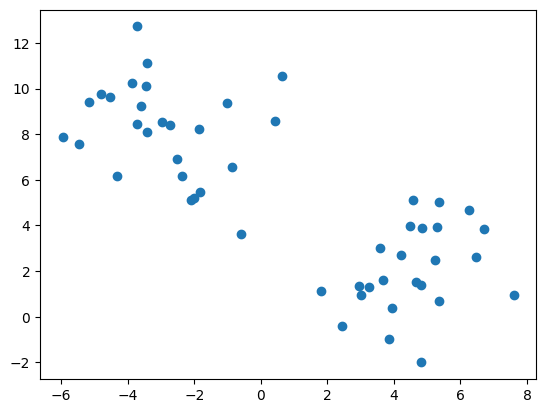

In [3]:
n_samples = 50
X = datasets.make_blobs(n_samples=n_samples,
                            centers=2,
                            cluster_std=2.,
                            random_state=42)[0]
plt.figure()
plt.scatter(X[:,0], X[:,1])

In [4]:
from cvxopt import matrix, solvers
import numpy as np
def separable_ocsvm_sphere_with_cvxopt(xall):
    nn = xall.shape[0]
    Kd = np.sum(xall * xall, 1)

    q = matrix(-Kd)
    P = matrix(2*xall.dot(xall.T))

    G = matrix(-np.eye(nn), (nn,nn))
    h = matrix(0.0, (nn,1))

    # sum(a_iy_i)=0
    A = matrix(1.0,(1,nn))
    b = matrix(1.0)

    sol=solvers.qp(P, q, G, h, A, b)
    a = np.array([cc for cc in sol['x']])

    c = a.reshape(1,-1).dot(xall)
    ii = np.argmax(a) # vector soporte
    r=np.linalg.norm(xall[ii]-c[0])
    return c, r, a

In [5]:
c, r, a = separable_ocsvm_sphere_with_cvxopt(X)

     pcost       dcost       gap    pres   dres
 0: -1.4032e+04 -7.3953e+01  5e+04  2e+02  6e-01
 1: -2.0246e+02 -7.3938e+01  5e+02  2e+00  6e-03
 2: -6.8580e+01 -7.2981e+01  8e+00  1e-02  4e-05
 3: -7.2243e+01 -7.2420e+01  3e-01  3e-04  9e-07
 4: -7.2389e+01 -7.2392e+01  3e-03  3e-06  1e-08
 5: -7.2391e+01 -7.2391e+01  3e-05  3e-08  1e-10
Optimal solution found.


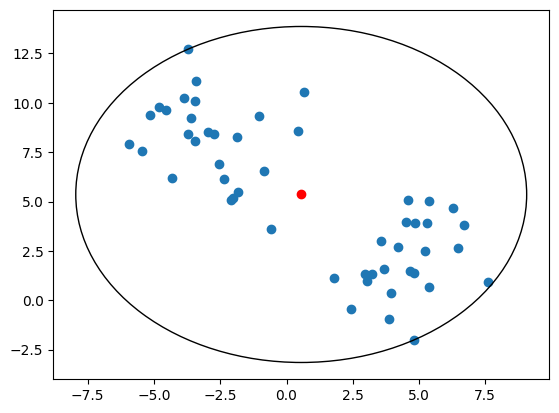

In [6]:
ff,aa = plt.subplots(1,1)
aa.scatter(X[:,0], X[:,1])
aa.scatter([c[0,0]],[c[0,1]],color='red')
circle1=plt.Circle(c[0], r, fill=False)
_=aa.add_patch(circle1)

#### Example 2

Now the data are in the **original space**, and we will use an RBF kernel as the *kernel* of the one class SVM.

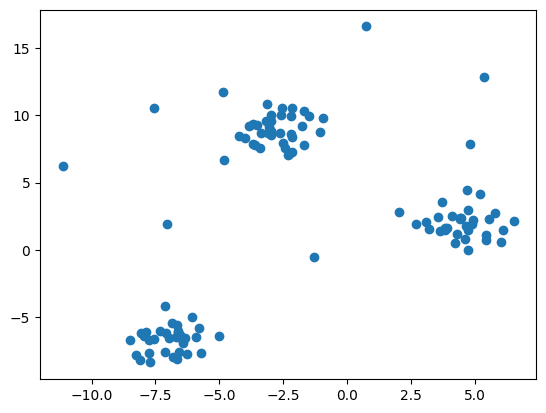

In [7]:
n_samples = 100
X = np.vstack((datasets.make_blobs(n_samples=n_samples,
                            centers=3,
                            cluster_std=1.,
                            random_state=42)[0],
               datasets.make_blobs(n_samples=10,
                            centers=1,
                            cluster_std=5.,
                            random_state=42)[0]
              ))
plt.figure()
_=plt.scatter(X[:,0], X[:,1])

In [8]:
from sklearn.metrics.pairwise import rbf_kernel
def kernel_ocsvm_sphere_with_cvxopt(K, C):
    nn = K.shape[0]
    q = matrix(-np.ones(nn), (nn,1))
    P = matrix(2*K)

    G = matrix(np.vstack((-np.eye(nn),
                          np.eye(nn)))
               )
    h = matrix(np.vstack((np.zeros(nn).reshape(-1,1),
                          C*np.ones(nn).reshape(-1,1)))
               )

    # sum(a_iy_i)=0
    A = matrix(1.0,(1,nn))
    b = matrix(1.0)

    sol=solvers.qp(P, q, G, h, A, b)
    a = np.array([cc for cc in sol['x']])

    return a

In [9]:
C=.05
gamma=.1
K=rbf_kernel(X, gamma=gamma)
alfa = kernel_ocsvm_sphere_with_cvxopt(K,
                                       C=C)

     pcost       dcost       gap    pres   dres
 0: -9.1005e-01 -6.5017e+00  2e+02  1e+01  3e-16
 1: -8.7561e-01 -6.0923e+00  7e+00  1e-01  4e-16
 2: -8.5986e-01 -1.2615e+00  4e-01  9e-17  4e-16
 3: -8.8732e-01 -1.0296e+00  1e-01  2e-16  3e-16
 4: -8.9732e-01 -9.3415e-01  4e-02  2e-16  3e-16
 5: -9.0468e-01 -9.1873e-01  1e-02  8e-17  3e-16
 6: -9.0705e-01 -9.1230e-01  5e-03  2e-16  3e-16
 7: -9.0841e-01 -9.0944e-01  1e-03  2e-16  3e-16
 8: -9.0881e-01 -9.0886e-01  5e-05  3e-16  3e-16
 9: -9.0882e-01 -9.0884e-01  2e-05  1e-16  3e-16
10: -9.0883e-01 -9.0883e-01  5e-07  1e-16  3e-16
Optimal solution found.


To calculate the radius of the sphere we need to identify a support vector that lies just above the surface of the sphere, i.e. at a distance from the centre of the sphere equal to the radius

In [10]:
tol = 1e-6 #tolerance to avoid numerical approximation errors

# we look for Support Vectors, those with alpha > 0
is_svs = alfa > tol

# observations within the sphere: inliers
within_margin = alfa < (C-tol)

# outliers are support vectors having a Lagrange multiplier equal to C
outliers = is_svs &( alfa >= (C-tol))

In [11]:
# Support vectors on the surface of the sphere, those having positive alpha (greater than zero) but less than C

ii = np.where(is_svs & within_margin)[0]

The radius can be calculated from the constraint of being inside the sphere of any of the support vectors resting on the surface of the sphere.

In [12]:
# we calculate the distance to the centre of all observations
distance_to_center = np.sqrt(1 - 2*K.dot(alfa.reshape(-1,1)) + alfa.reshape(1,-1).dot(K).dot(alfa))

In [13]:
# the radius is calculated by averaging the radii of the support vectors on the sphere's surface
radius = np.mean(distance_to_center[ii])

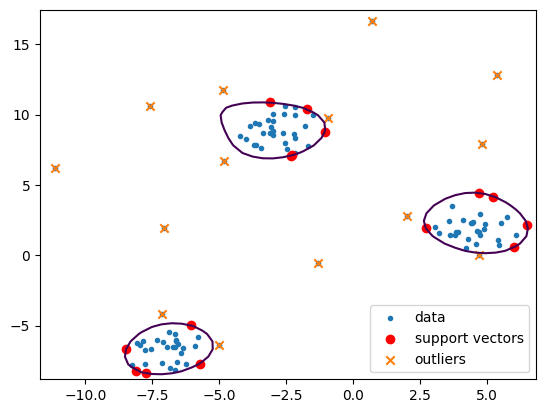

In [14]:
xmin = np.min(X[:,0])
xmax = np.max(X[:,0])
Xg = np.linspace(xmin-.05*np.absolute(xmin),
               xmax + .05*np.absolute(xmax),
               50) # or whatever values for x
ymin = np.min(X[:,1])
ymax = np.max(X[:,1])
Yg = np.linspace(ymin-.05*np.absolute(ymin),
               ymax + .05*np.absolute(ymax),
               50)   # or whatever values for y

XX, YY = np.meshgrid(Xg, Yg)
Xshape = XX.shape
Z = np.hstack((XX.reshape(-1,1), YY.reshape(-1,1)))
Kg = rbf_kernel(Z, X, gamma=gamma)
zz = np.sqrt(1 - 2*Kg.dot(alfa.reshape(-1,1)) + alfa.reshape(1,-1).dot(K).dot(alfa))
zz = zz.reshape(Xshape)

plt.figure()
plt.scatter(X[:,0], X[:,1], marker='.', label='data')

plt.scatter(X[ii,0], X[ii,1],color='r',label='support vectors')
plt.scatter(X[outliers,0], X[outliers,1], marker='x', label='outliers')

plt.contour(XX, YY, zz, [radius])
_=plt.legend(loc=4)



The contour in the figure above is the representation of the contour of the sphere in the input space, i.e. the 3 groups that appear in the image within the contours correspond to points that are inside the sphere in the feature space. The points marked with the crosses are outside the sphere in feature space.

## OneClassSVM in scikit learn

The class [`OneClassSVM`](https://scikit-learn.org/stable/modules/generated/sklearn.svm.OneClassSVM.html) contains an implementation of the algorithm based on sorting the training set **against the coordinate origin**.

The formulation it employs is a little different from the one we have seen. It is derived from the $\nu$-SVM, which basically replaces the hyperparameter $C$ that controls the soft margin with another hyperparameter $\nu$ that specifies the ratio of observations in the training set that are expected to end up as support vectors.

The way this class is used is very similar to that of the SVC class. Continuing with the example from before

In [15]:
from sklearn.svm import OneClassSVM

In [16]:
ocsvm = OneClassSVM(kernel='rbf',
                   nu=0.2, # parameter controling the percentage of SVs
                   gamma=.25).fit(X)


In [17]:
pred = ocsvm.predict(X)
outliers = pred==-1
svs=ocsvm.support_

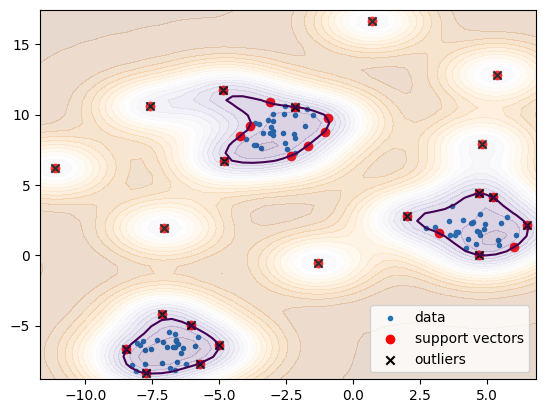

In [18]:
plt.figure()
plt.scatter(X[:,0], X[:,1], marker='.', label='data')

plt.scatter(X[svs,0], X[svs,1],color='r',label='support vectors')
plt.scatter(X[outliers,0], X[outliers,1], marker='x', color='black', label='outliers')

zz = ocsvm.decision_function(Z).reshape(Xshape)
cf=plt.contourf(XX, YY, zz, 20, cmap='PuOr', alpha=0.2)
plt.contour(XX, YY, zz, [0])
_=plt.legend(loc=4)

## Example with real data

Let's load the MNIST data set

In [19]:
import ssl

try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    # Legacy Python that doesn't verify HTTPS certificates by default
    pass
else:
    # Handle target environment that doesn't support HTTPS verification
    ssl._create_default_https_context = _create_unverified_https_context

data = np.loadtxt("http://www.tsc.uc3m.es/~vanessa/data_notebooks/mnist/mnist_test.csv", delimiter=",")
fac = 0.99 / 255
X=np.asarray(data[:, 1:]) * fac + 0.01
Y = np.array([int(cc) for cc in data[:, 0]])

And let's consider that `7`'s are normal data

In [20]:
clase = 7
datos = X[Y==clase,:]

In [21]:
ocsvm = OneClassSVM(kernel='rbf',
                   nu=0.01, # to control the number of SVs
                   gamma=0.01).fit(datos)

# Analyze number the outliers in training data to check 1SVM parameters
pred_train = ocsvm.predict(datos)
false_negative = np.mean(pred_train<0)
print("False negative rate {0:.2f}".format(false_negative))

False negative rate 0.02


In [22]:
def plot_ten_examples(X,y, score=None):
  nrows = 2
  ncols = 5
  ff,aa = plt.subplots(nrows, ncols,figsize=(12,2))
  ii = 0
  for rr in range(nrows):
    for cc in range(ncols):
      aa[rr][cc].set_axis_off()
      aa[rr][cc].imshow(X[ii].reshape(28,28), cmap=plt.cm.gray_r, interpolation='nearest')
      if score is None:
        aa[rr][cc].set_title('Target: {0:d}'.format(y[ii]))
      else:
        aa[rr][cc].set_title('Target: {0:d}, score:{1:.3f}'.format(y[ii], score[ii]))
      ii += 1
  ff.tight_layout()

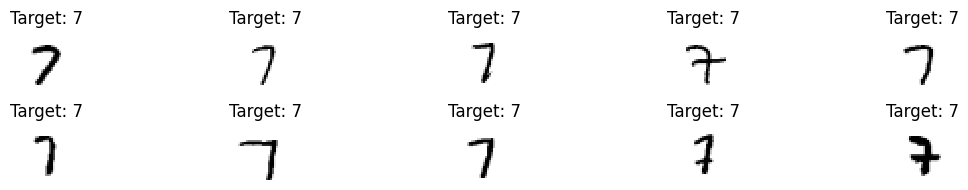

In [23]:
plot_ten_examples(datos[25:35,:],[clase]*10)

In [24]:
score = ocsvm.decision_function(datos)
orden = np.argsort(score)

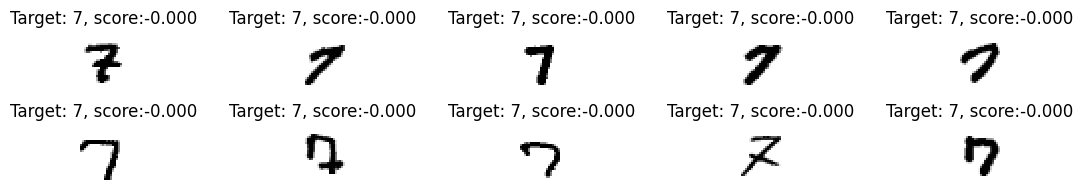

In [25]:
# The most atypical data
plot_ten_examples(datos[orden[:10],:],[clase]*10, score[orden[:10]])

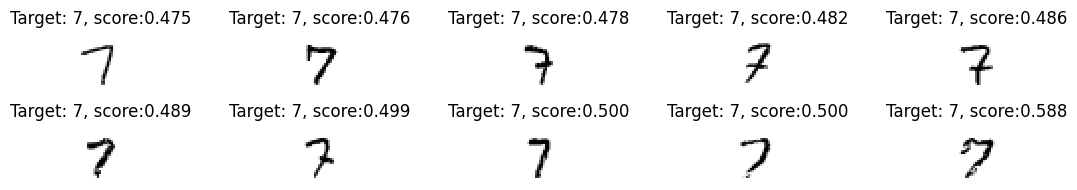

In [26]:
# The most typical data
plot_ten_examples(datos[orden[-10:],:],[clase]*10, score[orden[-10:]])

Let's analyze the model behaviour when we pass `2`'s

In [27]:
clase_out = 2
datos_out = X[Y==clase_out,:]

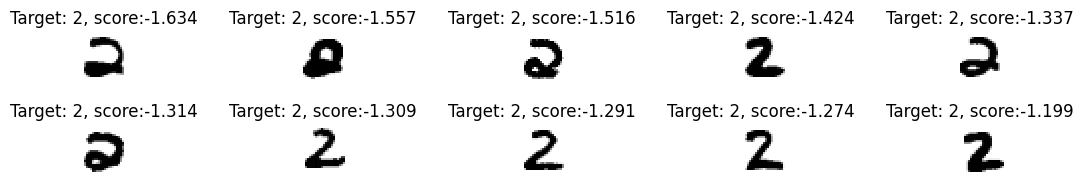

In [28]:
score_out = ocsvm.decision_function(datos_out)
orden_out = np.argsort(score_out)
plot_ten_examples(datos_out[orden_out[:10],:],[clase_out]*10, score_out[orden_out[:10]])

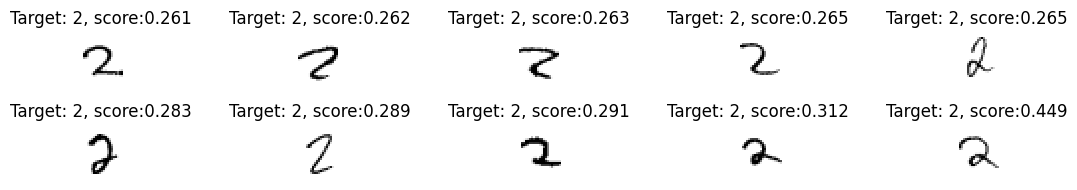

In [29]:
plot_ten_examples(datos_out[orden_out[-10:],:],[clase_out]*10, score_out[orden_out[-10:]])

# Parameter selection

To implement the `OneClassSVM` model, we have to select `gamma` and `nu`, but there are not labels to apply a CV. How can I select these parameters???

Let's iterate through a combination of these hyperparameters, train a `OneClassSVM` model and calculate the false negative rate and the number of support vectors...

In [30]:
gamma_values = [1e-4, 0.001, 0.01, 0.1]
nu_values = [0.01, 0.05, 0.1]

print("Gamma values:", gamma_values)
print("Nu values:", nu_values)

Gamma values: [0.0001, 0.001, 0.01, 0.1]
Nu values: [0.01, 0.05, 0.1]


In [31]:
import numpy as np
from sklearn.svm import OneClassSVM

# Initialize an empty list to store results
results = []

# Loop through each combination of gamma and nu
for gamma in gamma_values:
    for nu in nu_values:
        print(f"Training OneClassSVM with gamma={gamma}, nu={nu}")

        # Initialize and train OneClassSVM
        ocsvm = OneClassSVM(kernel='rbf', nu=nu, gamma=gamma)
        ocsvm.fit(datos)

        # Calculate false negative rate
        pred_train = ocsvm.predict(datos)
        false_negative_rate = np.mean(pred_train == -1) # -1 indicates outliers

        # Get the number of support vectors
        n_support_vectors = len(ocsvm.support_vectors_)

        # Store metrics
        results.append({
            'gamma': gamma,
            'nu': nu,
            'false_negative_rate': false_negative_rate,
            'n_support_vectors': n_support_vectors
        })


Training OneClassSVM with gamma=0.0001, nu=0.01
Training OneClassSVM with gamma=0.0001, nu=0.05
Training OneClassSVM with gamma=0.0001, nu=0.1
Training OneClassSVM with gamma=0.001, nu=0.01
Training OneClassSVM with gamma=0.001, nu=0.05
Training OneClassSVM with gamma=0.001, nu=0.1
Training OneClassSVM with gamma=0.01, nu=0.01
Training OneClassSVM with gamma=0.01, nu=0.05
Training OneClassSVM with gamma=0.01, nu=0.1
Training OneClassSVM with gamma=0.1, nu=0.01
Training OneClassSVM with gamma=0.1, nu=0.05
Training OneClassSVM with gamma=0.1, nu=0.1


In [32]:
import pandas as pd

# Display results
results_df = pd.DataFrame(results)
print("\nHyperparameter Tuning Results:")
print(results_df)


Hyperparameter Tuning Results:
     gamma    nu  false_negative_rate  n_support_vectors
0   0.0001  0.01             0.013619                 19
1   0.0001  0.05             0.048638                 57
2   0.0001  0.10             0.101167                108
3   0.0010  0.01             0.014591                 20
4   0.0010  0.05             0.050584                 59
5   0.0010  0.10             0.100195                107
6   0.0100  0.01             0.021401                 40
7   0.0100  0.05             0.052529                 67
8   0.0100  0.10             0.104086                116
9   0.1000  0.01             0.441634                714
10  0.1000  0.05             0.357004                723
11  0.1000  0.10             0.372568                726
